In [1]:
# Load packages
library(dplyr)
library(tidyr)
library(hms)
library(lubridate)
library(ggplot2)
library(purrr)
library(patchwork)
library(tidyverse)
# library(reshape2)
library(stringr)



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘lubridate’


The following object is masked from ‘package:hms’:

    hms


The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats 1.0.1     ✔ stringr 1.5.2
✔ readr   2.1.5     ✔ tibble  3.3.0
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter()  masks stats::filter()
✖ lubridate::hms() masks hms::hms()
✖ dplyr::lag()     masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [6]:
# Load tsv 
od600 <- read_tsv("od600_080726.tsv")
head(od600)

Rows: 36 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (2): Strain, Carbon
dbl (3): OD600, Time_hr, Replicate

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Strain,Carbon,OD600,Time_hr,Replicate
<chr>,<chr>,<dbl>,<dbl>,<dbl>
ATCC_43300,M9_GLU,0.030,0,1
ATCC_43300,M9_GLU,0.020,0,2
ATCC_43300,M9_GLU,0.030,0,3
ATCC_43300,M9_SIA,0.038,0,1
ATCC_43300,M9_SIA,0.032,0,2
ATCC_43300,M9_SIA,0.030,0,3


In [7]:
long_od <- od600

In [8]:
# Remove unused wells
long_od <- long_od %>%
  filter(!is.na(Strain))

head(long_od)
tail(long_od)

Strain,Carbon,OD600,Time_hr,Replicate
<chr>,<chr>,<dbl>,<dbl>,<dbl>
ATCC_43300,M9_GLU,0.030,0,1
ATCC_43300,M9_GLU,0.020,0,2
ATCC_43300,M9_GLU,0.030,0,3
ATCC_43300,M9_SIA,0.038,0,1
ATCC_43300,M9_SIA,0.032,0,2
ATCC_43300,M9_SIA,0.030,0,3


Strain,Carbon,OD600,Time_hr,Replicate
<chr>,<chr>,<dbl>,<dbl>,<dbl>
ATCC_43300,M9_GMP,0.048,48,1
ATCC_43300,M9_GMP,0.060,48,2
ATCC_43300,M9_GMP,0.050,48,3
ATCC_43300,M9,0.070,48,1
ATCC_43300,M9,0.060,48,2
ATCC_43300,M9,0.041,48,3


`geom_smooth()` using formula = 'y ~ x'
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“pseudoinverse used at -0.24”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“neighborhood radius 48.24”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“reciprocal condition number  8.8527e-17”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“There are other near singularities as well. 2327.1”
Warning message in predLoess(object$y, object$x, newx = if (is.null(newdata)) object$x else if (is.data.frame(newdata)) as.matrix(model.frame(delete.response(terms(object)), :
“pseudoinverse used at -0.24”
Warning message in predLoess(object$y, object$x, newx = if (is.null(newdata)) object$x else if (is.data.frame(newdata)) as.matrix(model.frame(delete.response(terms(object)), :
“neighborhood radius 48.24”
Warning message in predLoess(object$y

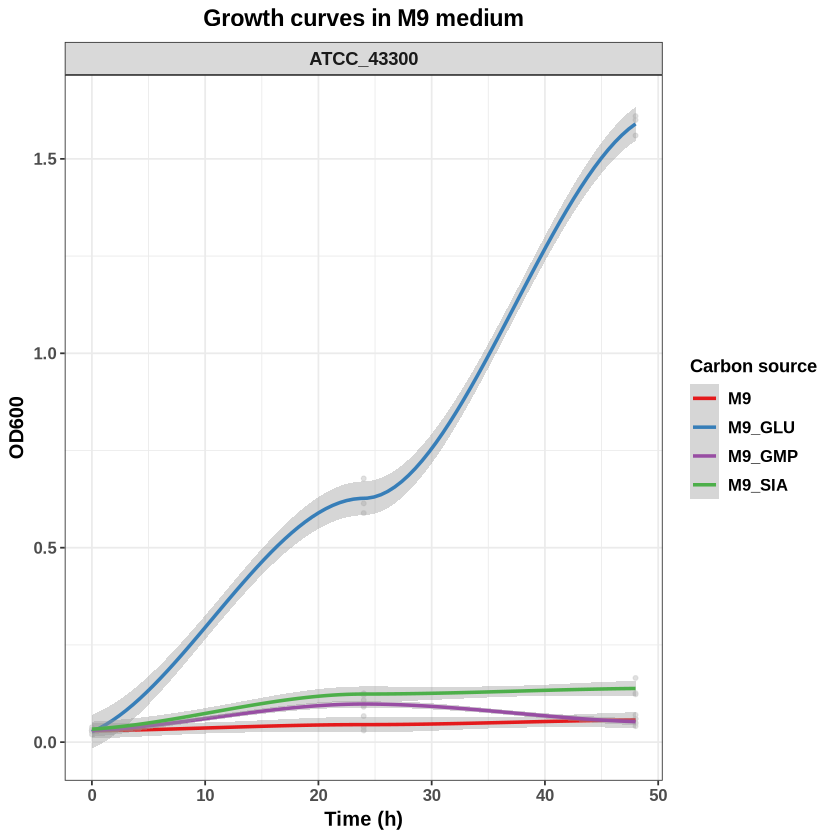

In [11]:
plotA <- ggplot(
  long_od %>%
    filter(Strain != "None"),   # remove negative controls
  aes(x = Time_hr, y = OD600)
) +
  # Raw measurements in light gray
  geom_point(
    aes(group = Replicate),
    color = "lightgray",
    size = 1,
    alpha = 0.7
  ) +

  # Loess trend colored by carbon source
  geom_smooth(
    aes(color = Carbon, group = Carbon),
    method = "loess",
    span = 0.8,
    se = TRUE,
    linewidth = 1
  ) +

  facet_wrap(~Strain, scales = "free_y") +

  scale_color_manual(
  values = c(
    "M9"       = "#E41A1C",
    "M9_GLU"  = "#377EB8",
    "M9_SIA"   = "#4DAF4A",
    "M9_GMP"      = "#984EA3"
  )
) +

  labs(
    x = "Time (h)",
    y = "OD600",
    color = "Carbon source",
    title = "Growth curves in M9 medium"
  ) +

  theme_bw() +
  theme(
    axis.title = element_text(face = "bold", size = 12),
    axis.text = element_text(face = "bold", size = 10),
    strip.text = element_text(face = "bold", size = 11),
    legend.title = element_text(face = "bold", size = 11),
    legend.text = element_text(face = "bold", size = 10),
    plot.title = element_text(face = "bold", size = 14, hjust = 0.5)
  )

plotA

In [13]:
# Explore relative growth to assess carbohydrate catabolism (tp 24h)
# Step 1 — extract endpoint (24h)
od_24h <- long_od %>%
  filter(Time_hr == 24)
head(od_24h)

# 2. Step 2 — compute relative growth vs M9 (per strain + replicate)
od_rel <- od_24h %>%
  group_by(Strain) %>%
  mutate(
    m9_baseline = mean(OD600[Carbon == "M9"], na.rm = TRUE),
    rel_growth = OD600 / m9_baseline
  ) %>%
  ungroup()
head(od_rel)

# 3. Step 3 — summary stats
summary_od24 <- od_rel %>%
  group_by(Strain, Carbon) %>%
  summarise(
    mean_rel = mean(rel_growth, na.rm = TRUE),
    sd_rel   = sd(rel_growth, na.rm = TRUE),
    sem_rel  = sd(rel_growth) / sqrt(n()),
    n        = n(),
    .groups = "drop"
  )
head(summary_od24)

Strain,Carbon,OD600,Time_hr,Replicate
<chr>,<chr>,<dbl>,<dbl>,<dbl>
ATCC_43300,M9_GLU,0.678,24,1
ATCC_43300,M9_GLU,0.589,24,2
ATCC_43300,M9_GLU,0.614,24,3
ATCC_43300,M9_SIA,0.125,24,1
ATCC_43300,M9_SIA,0.121,24,2
ATCC_43300,M9_SIA,0.125,24,3


Strain,Carbon,OD600,Time_hr,Replicate,m9_baseline,rel_growth
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ATCC_43300,M9_GLU,0.678,24,1,0.045,15.066667
ATCC_43300,M9_GLU,0.589,24,2,0.045,13.088889
ATCC_43300,M9_GLU,0.614,24,3,0.045,13.644444
ATCC_43300,M9_SIA,0.125,24,1,0.045,2.777778
ATCC_43300,M9_SIA,0.121,24,2,0.045,2.688889
ATCC_43300,M9_SIA,0.125,24,3,0.045,2.777778


Strain,Carbon,mean_rel,sd_rel,sem_rel,n
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<int>
ATCC_43300,M9,1.000000,0.43262050,0.24977356,3
ATCC_43300,M9_GLU,13.933333,1.02004599,0.58892383,3
ATCC_43300,M9_GMP,2.177778,0.19751543,0.11403559,3
ATCC_43300,M9_SIA,2.748148,0.05132002,0.02962963,3


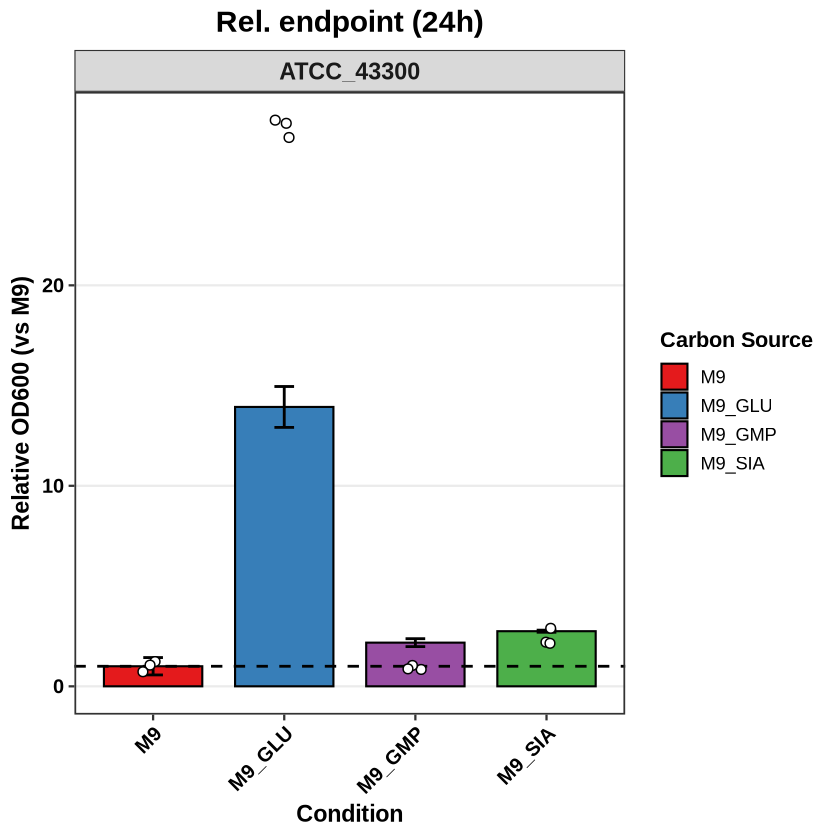

In [20]:
# Plot
library(ggplot2)

barplot24h <- ggplot(summary_od24, aes(x = Carbon, y = mean_rel, fill = Carbon)) +
  
  geom_col(
    color = "black",
    width = 0.75,
    linewidth = 0.6
  ) +
  
  geom_errorbar(
    aes(
      ymin = mean_rel - sd_rel,
      ymax = mean_rel + sd_rel
    ),
    width = 0.15,
    linewidth = 0.8
  ) +
  geom_hline(
  yintercept = 1,
  linetype = "dashed",
  linewidth = 0.8,
  color = "black"
) +
  geom_jitter(
    data = od_rel,
    aes(x = Carbon, y = rel_growth),
    width = 0.08,
    size = 2.3,
    shape = 21,
    fill = "white",
    color = "black"
  ) +
  
  facet_wrap(~Strain, ncol = 2) +
  
  scale_fill_manual(values = c(
      "M9"       = "#E41A1C",
      "M9_GLU"  = "#377EB8",
      "M9_SIA"   = "#4DAF4A",
      "M9_GMP"      = "#984EA3"  )) +
  
  labs(
    title = "Rel. endpoint (24h)",
    x = "Condition",
    y = "Relative OD600 (vs M9)",
    fill = "Carbon Source"
  ) +
  
  theme_bw(base_size = 14) +
  
  theme(
    plot.title = element_text(size = 18, face = "bold", hjust = 0.5),
    strip.text = element_text(size = 14, face = "bold"),
    axis.title = element_text(size = 14, face = "bold"),
    axis.text = element_text(size = 12, face = "bold", colour = "black"),
    axis.text.x = element_text(angle = 45, hjust = 1),
    legend.title = element_text(size = 13, face = "bold"),
    legend.text = element_text(size = 11),
    panel.grid.major.x = element_blank(),
    panel.grid.minor = element_blank(),
    panel.border = element_rect(linewidth = 1)
  )
barplot24h

In [16]:
# Explore relative growth to assess carbohydrate catabolism (tp 48h)
# Step 1 — extract endpoint (48h)
od_48h <- long_od %>%
  filter(Time_hr == 48)
head(od_48h)

# 2. Step 2 — compute relative growth vs M9 (per strain + replicate)
od_rel <- od_48h %>%
  group_by(Strain) %>%
  mutate(
    m9_baseline = mean(OD600[Carbon == "M9"], na.rm = TRUE),
    rel_growth = OD600 / m9_baseline
  ) %>%
  ungroup()
head(od_rel)

# 3. Step 3 — summary stats
summary_od48 <- od_rel %>%
  group_by(Strain, Carbon) %>%
  summarise(
    mean_rel = mean(rel_growth, na.rm = TRUE),
    sd_rel   = sd(rel_growth, na.rm = TRUE),
    sem_rel  = sd(rel_growth) / sqrt(n()),
    n        = n(),
    .groups = "drop"
  )
head(summary_od48)

Strain,Carbon,OD600,Time_hr,Replicate
<chr>,<chr>,<dbl>,<dbl>,<dbl>
ATCC_43300,M9_GLU,1.610,48,1
ATCC_43300,M9_GLU,1.560,48,2
ATCC_43300,M9_GLU,1.600,48,3
ATCC_43300,M9_SIA,0.126,48,1
ATCC_43300,M9_SIA,0.123,48,2
ATCC_43300,M9_SIA,0.165,48,3


Strain,Carbon,OD600,Time_hr,Replicate,m9_baseline,rel_growth
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ATCC_43300,M9_GLU,1.610,48,1,0.057,28.245614
ATCC_43300,M9_GLU,1.560,48,2,0.057,27.368421
ATCC_43300,M9_GLU,1.600,48,3,0.057,28.070175
ATCC_43300,M9_SIA,0.126,48,1,0.057,2.210526
ATCC_43300,M9_SIA,0.123,48,2,0.057,2.157895
ATCC_43300,M9_SIA,0.165,48,3,0.057,2.894737


Strain,Carbon,mean_rel,sd_rel,sem_rel,n
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<int>
ATCC_43300,M9,1.0000000,0.2584372,0.14920878,3
ATCC_43300,M9_GLU,27.8947368,0.4641669,0.26798688,3
ATCC_43300,M9_GMP,0.9239766,0.1127912,0.06512005,3
ATCC_43300,M9_SIA,2.4210526,0.4110658,0.23732893,3


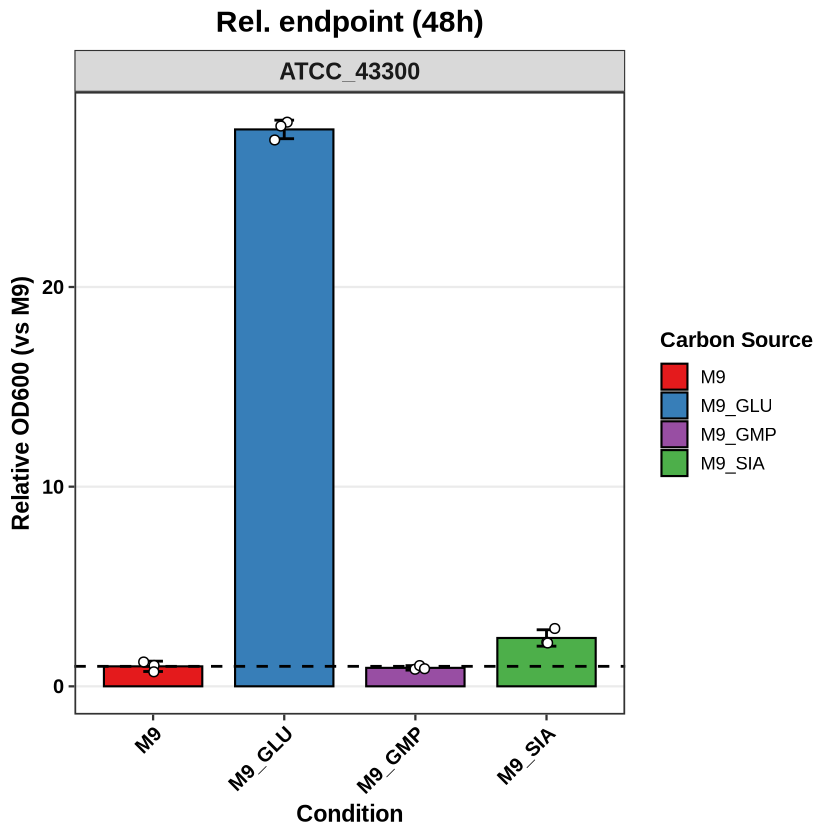

In [19]:
# Plot
library(ggplot2)

barplot48h <- ggplot(summary_od48, aes(x = Carbon, y = mean_rel, fill = Carbon)) +
  
  geom_col(
    color = "black",
    width = 0.75,
    linewidth = 0.6
  ) +
  
  geom_errorbar(
    aes(
      ymin = mean_rel - sd_rel,
      ymax = mean_rel + sd_rel
    ),
    width = 0.15,
    linewidth = 0.8
  ) +
  geom_hline(
  yintercept = 1,
  linetype = "dashed",
  linewidth = 0.8,
  color = "black"
) +
  geom_jitter(
    data = od_rel,
    aes(x = Carbon, y = rel_growth),
    width = 0.08,
    size = 2.3,
    shape = 21,
    fill = "white",
    color = "black"
  ) +
  
  facet_wrap(~Strain, ncol = 2) +
  
  scale_fill_manual(values = c(
      "M9"       = "#E41A1C",
      "M9_GLU"  = "#377EB8",
      "M9_SIA"   = "#4DAF4A",
      "M9_GMP"      = "#984EA3"  )) +
  
  labs(
    title = "Rel. endpoint (48h)",
    x = "Condition",
    y = "Relative OD600 (vs M9)",
    fill = "Carbon Source"
  ) +
  
  theme_bw(base_size = 14) +
  
  theme(
    plot.title = element_text(size = 18, face = "bold", hjust = 0.5),
    strip.text = element_text(size = 14, face = "bold"),
    axis.title = element_text(size = 14, face = "bold"),
    axis.text = element_text(size = 12, face = "bold", colour = "black"),
    axis.text.x = element_text(angle = 45, hjust = 1),
    legend.title = element_text(size = 13, face = "bold"),
    legend.text = element_text(size = 11),
    panel.grid.major.x = element_blank(),
    panel.grid.minor = element_blank(),
    panel.border = element_rect(linewidth = 1)
  )
barplot48h

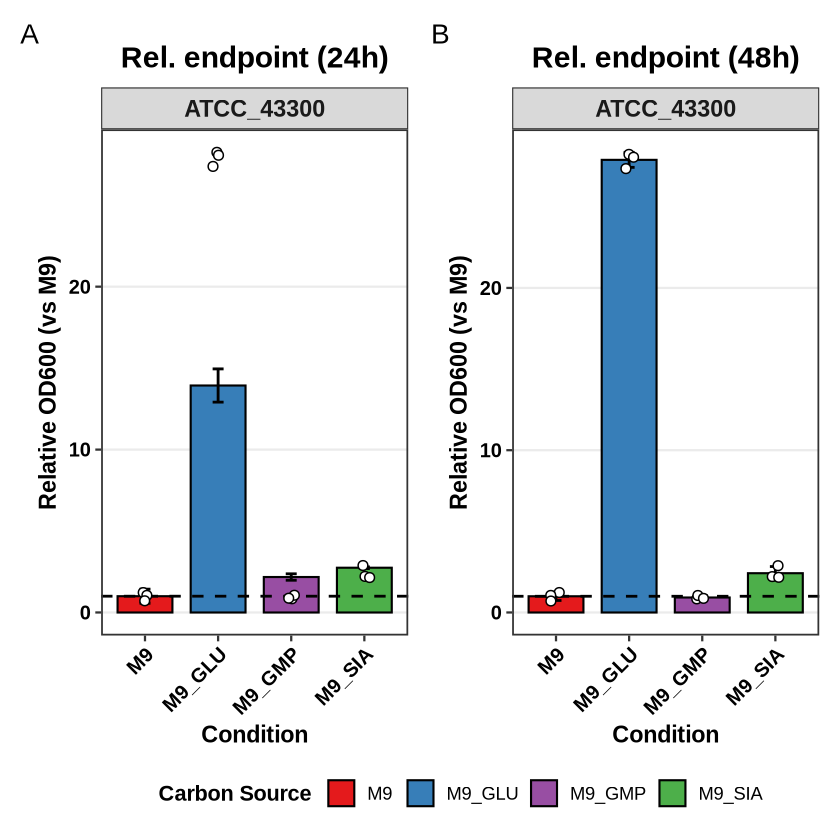

In [21]:
library(patchwork)

panel_AB <- (barplot24h + barplot48h) +
  plot_layout(guides = "collect") +
  plot_annotation(tag_levels = "A") &
  theme(
    legend.position = "bottom"
  )

panel_AB

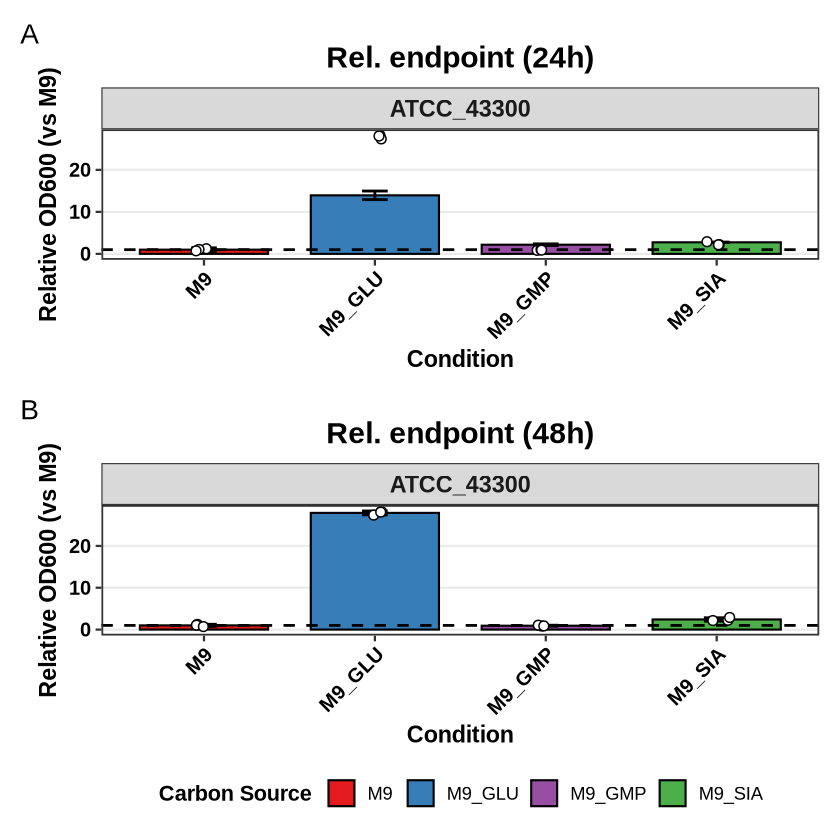

In [25]:
library(patchwork)

panel_AB <- (barplot24h / barplot48h) +
  plot_layout(guides = "collect") +
  plot_annotation(tag_levels = "A") &
  theme(
    legend.position = "bottom"
  )

panel_AB

In [26]:
# COPY STATS SCRIPT FROM LABS COMPUTER